# Surgical Data Analysis Project

This Jupyter notebook is dedicated to the analysis and modeling of surgical data to predict various outcomes based on patient characteristics and surgical parameters. The dataset includes various features like age, BMI, and complications during surgery.

## Objective
The main objective of this project is to perform a comprehensive exploratory data analysis (EDA) followed by building predictive models to understand factors that contribute significantly to surgical complications.

## Dataset Overview
The dataset consists of multiple features related to surgical procedures and patient details, which we will explore through visual and statistical methods.


## Data Loading and Initial Exploration

We begin by loading the necessary libraries and the dataset. Then, we will perform initial data exploration to understand the basic structure and content of the data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from sklearn import svm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Load the dataset
data_path = '/content/Surgical-deepnet.csv'
data = pd.read_csv(data_path)
display(data.head())
display(data.describe())


,bmi,Age,asa_status,baseline_cancer,baseline_charlson,baseline_cvd,baseline_dementia,baseline_diabetes,baseline_digestive,baseline_osteoart,...,complication_rsi,dow,gender,hour,month,moonphase,mort30,mortality_rsi,race,complication
0,19.31,59.2,1,1,0,0,0,0,0,0,...,-0.57,3,0,7.63,6,1,0,-0.43,1,0
1,18.73,59.1,0,0,0,0,0,0,0,0,...,0.21,0,0,12.93,0,1,0,-0.41,1,0
2,21.85,59.0,0,0,0,0,0,0,0,0,...,0.00,2,0,7.68,5,3,0,0.08,1,0
3,18.49,59.0,1,0,1,0,0,1,1,0,...,-0.65,2,1,7.58,4,3,0,-0.32,1,0
4,19.70,59.0,1,0,0,0,0,0,0,0,...,0.00,0,0,7.88,11,0,0,0.00,1,0


,bmi,Age,asa_status,baseline_cancer,baseline_charlson,baseline_cvd,baseline_dementia,baseline_diabetes,baseline_digestive,baseline_osteoart,...,complication_rsi,dow,gender,hour,month,moonphase,mort30,mortality_rsi,race,complication
count,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,...,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000
mean,31.295642,63.205268,0.632320,0.262316,0.977520,0.620294,0.004851,0.120875,0.189546,0.342740,...,-0.699044,1.606970,0.548890,10.171613,5.915408,1.187086,0.003963,-0.836712,0.919440,0.252135
std,8.152709,18.088191,0.539952,0.439909,1.758355,0.485330,0.069485,0.325993,0.391955,0.474642,...,1.339394,1.497738,0.497621,2.659881,3.239825,1.158357,0.062830,1.194111,0.364663,0.434253
min,2.150000,6.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-4.720000,0.000000,0.000000,6.070000,0.000000,0.000000,0.000000,-3.820000,0.000000,0.000000
25%,26.510000,51.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.970000,0.000000,0.000000,7.820000,3.000000,0.000000,0.000000,-2.250000,1.000000,0.000000
50%,28.980000,59.700000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,-0.580000,1.000000,1.000000,9.120000,7.000000,1.000000,0.000000,-0.640000,1.000000,0.000000
75%,35.295000,74.700000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,3.000000,1.000000,12.050000,8.000000,2.000000,0.000000,0.000000,1.000000,1.000000
max,92.590000,90.000000,2.000000,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,12.560000,4.000000,1.000000,18.920000,11.000000,3.000000,1.000000,4.400000,2.000000,1.000000


## Exploratory Data Analysis

In this section, we'll dive deeper into the dataset to identify missing values, outliers, and understand the distribution of various features.


,Total Missing,Percentage


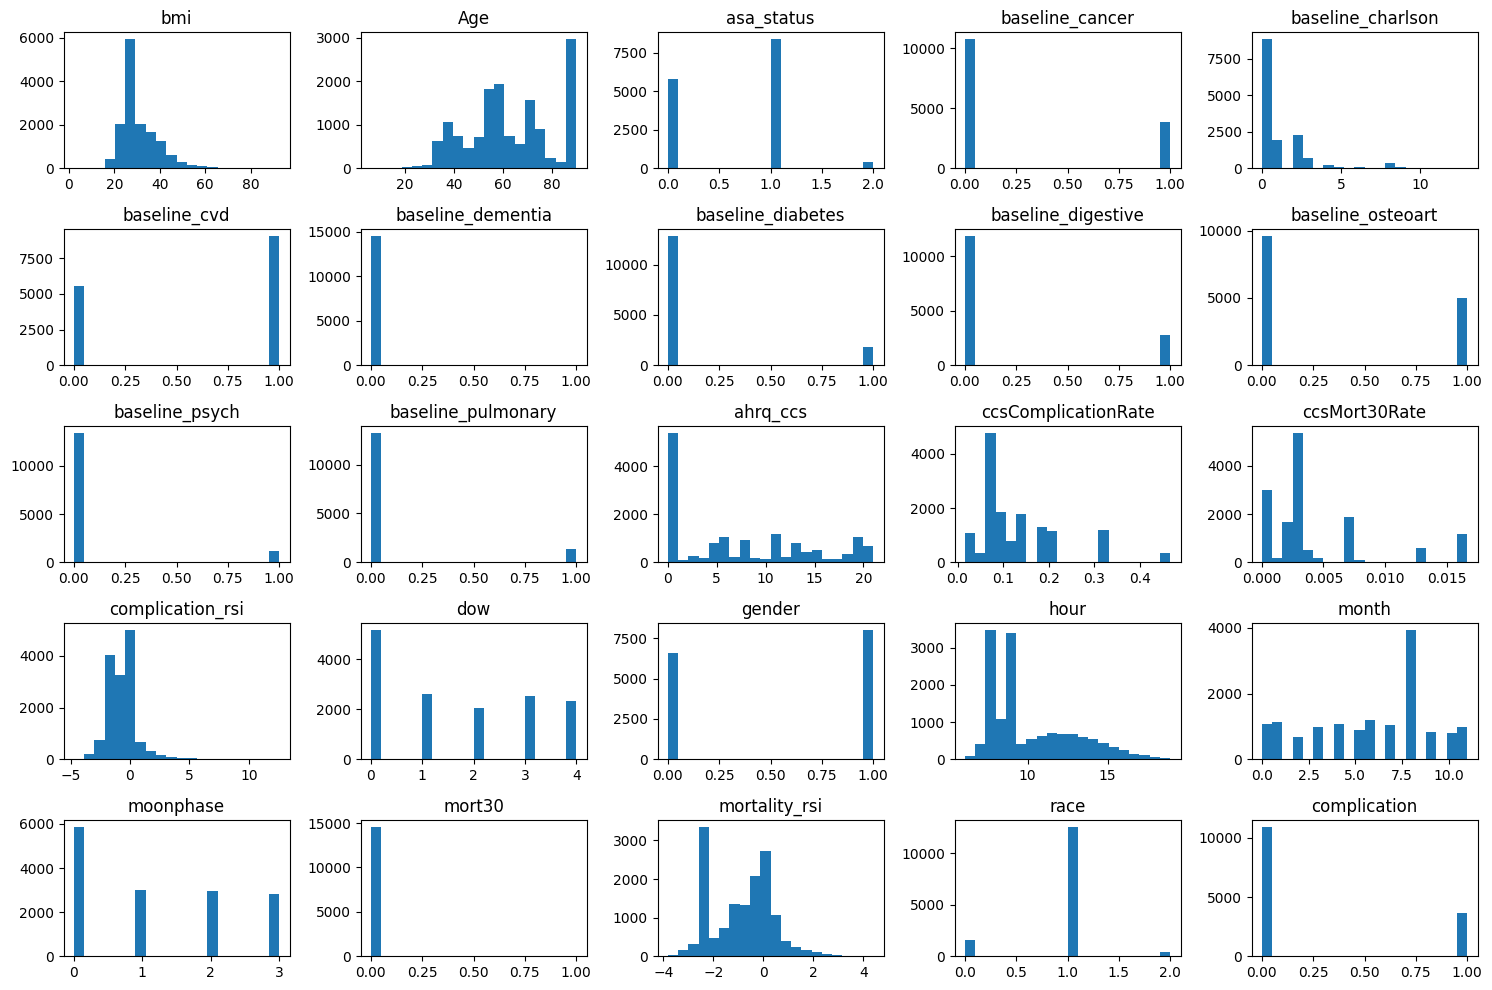

In [ ]:
# Missing values
missing_data = data.isnull().sum().sort_values(ascending=False)
missing_percent = (data.isnull().sum() / data.isnull().count() * 100).sort_values(ascending=False)
missing_info = pd.DataFrame({'Total Missing': missing_data, 'Percentage': missing_percent})
display(missing_info[missing_info['Total Missing'] > 0])

# Histograms for numerical data
data.hist(bins=20, figsize=(15, 10), grid=False)
plt.tight_layout()


## Data Visualization

We will now visualize key relationships and distributions within the data, helping to uncover patterns and insights.


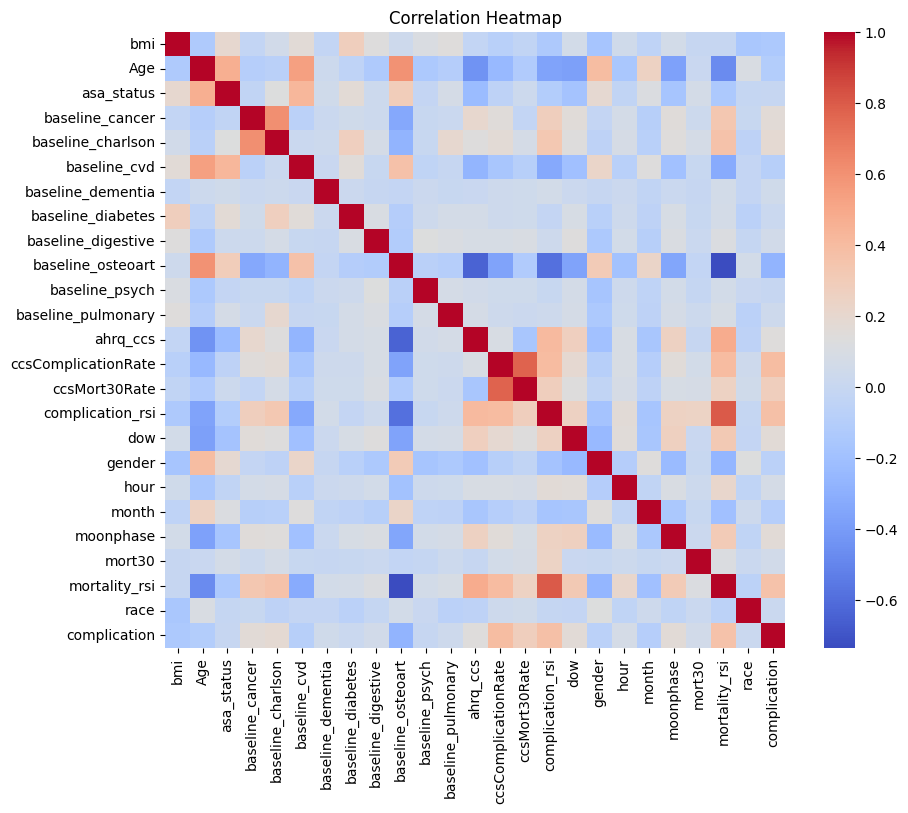

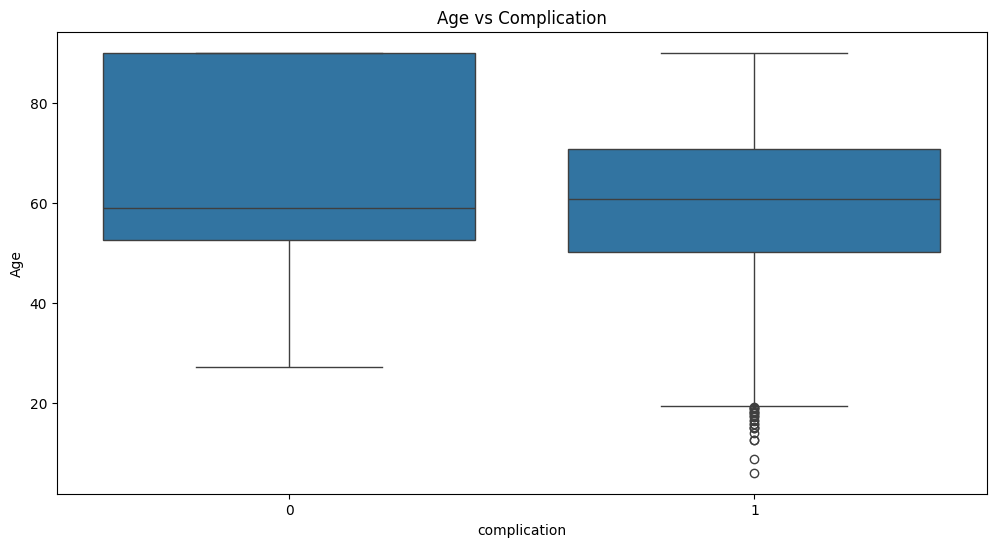

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Box plots for categorical variables
plt.figure(figsize=(12, 6))
sns.boxplot(x='complication', y='Age', data=data)
plt.title('Age vs Complication')
plt.show()


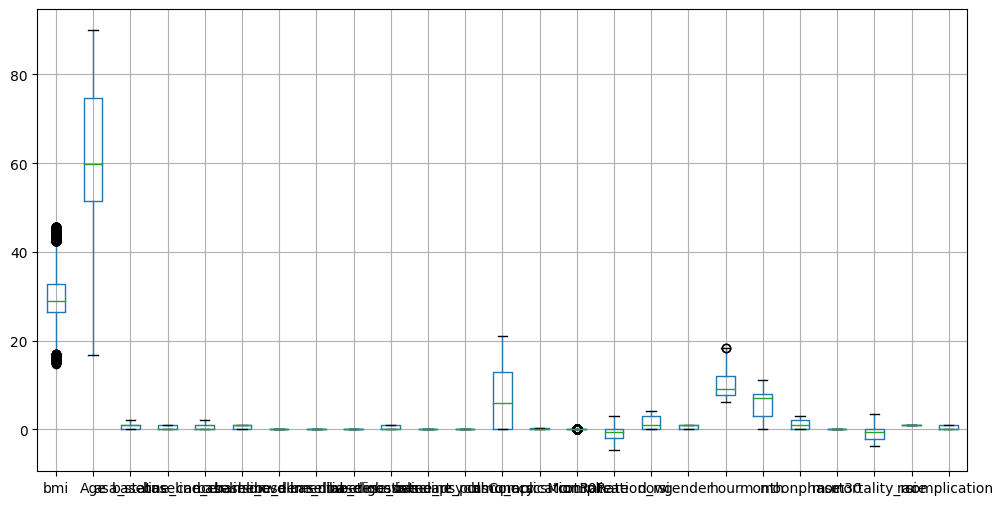

In [ ]:
#Remove outliers
def remove_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))]
    return data

data = remove_outliers(data)
# Remove NaN values with median
data = data.fillna(data.median())

# Check if there are any outliers
data.boxplot(figsize=(12, 6))
plt.show()

## Data Modeling and Evaluation

Next, we will use machine learning models to predict surgical outcomes based on the cleaned and processed data.


                     Accuracy  F1 Score  Precision    Recall
Logistic Regression  0.795354  0.455949   0.658793  0.348611
Random Forest        0.851725  0.638333   0.797917  0.531944
Gradient Boosting    0.902289  0.771200   0.909434  0.669444
The highest accuracy is 0.8373576309794988
The best model is Decision Tree


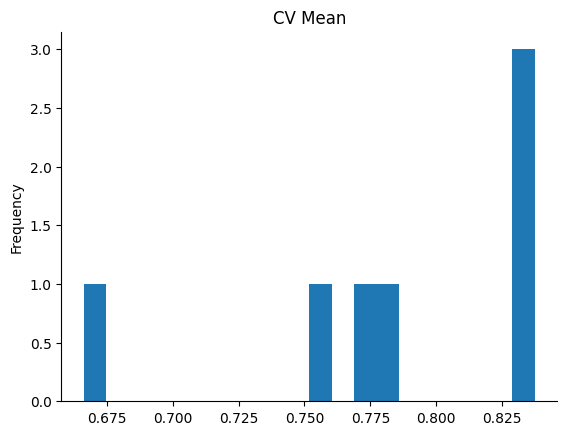

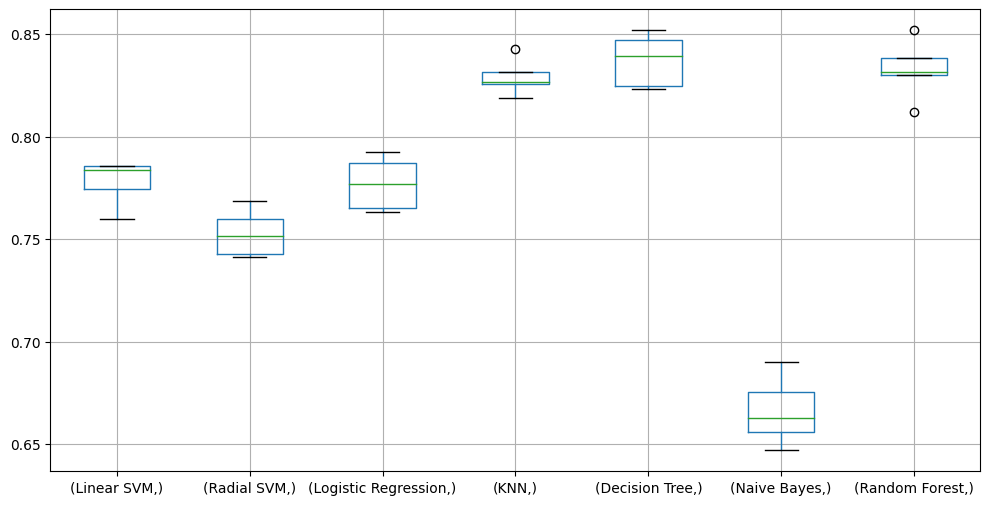

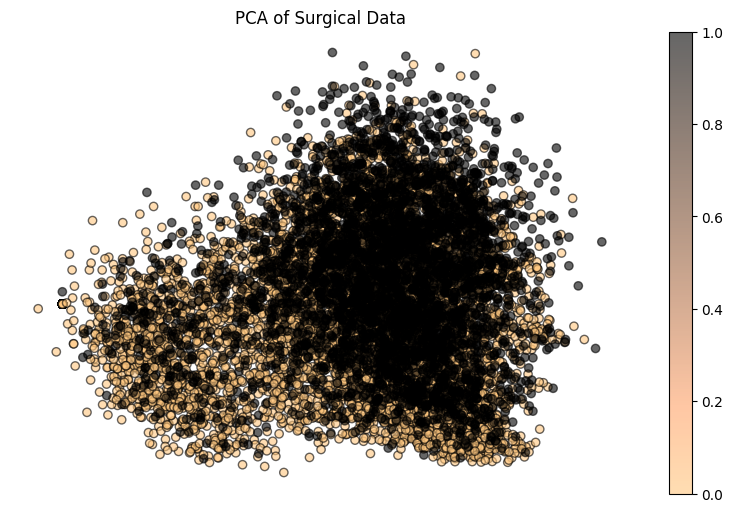

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Data Modeling and Evaluation

# Define the features and target variable
X = data.drop('complication', axis=1)
y = data['complication']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
np.random.seed(42)  # For reproducibility
sample_indices = np.random.choice(X.index, size=int(len(X) * 0.3), replace=False)  # Sample 30% of data
X_sample = X.loc[sample_indices]
Y_sample = y.loc[sample_indices]


# Initialize the models
logistic_model = LogisticRegression(max_iter=1000)
random_forest_model = RandomForestClassifier(n_estimators=100)
gbm_model = GradientBoostingClassifier(n_estimators=100)

# Fit the models
logistic_model.fit(X_train_scaled, y_train)
random_forest_model.fit(X_train, y_train)  # Random forest does not require feature scaling
gbm_model.fit(X_train, y_train)

# Make predictions and evaluate the models
model_performance = {}
for model, name in [(logistic_model, "Logistic Regression"), (random_forest_model, "Random Forest"), (gbm_model, "Gradient Boosting")]:
    preds = model.predict(X_test_scaled if "Logistic" in name else X_test)
    model_performance[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds)
    }

performance_df = pd.DataFrame(model_performance).T
print(performance_df)


# K-Fold Cross-validation setup
kfold = KFold(n_splits=5, shuffle=True, random_state=22)

# List of classifiers
classifiers = ['Linear SVM', 'Radial SVM', 'Logistic Regression', 'KNN', 'Decision Tree', 'Naive Bayes', 'Random Forest']
models = [
    svm.SVC(kernel='linear'),
    svm.SVC(kernel='rbf'),
    LogisticRegression(max_iter=1000),
    KNeighborsClassifier(n_neighbors=9),
    DecisionTreeClassifier(),
    GaussianNB(),
    RandomForestClassifier(n_estimators=50)
]

# Lists to store results
result = []
std = []
accuracy = []

for model in models:
    cv_result = cross_val_score(model, X_sample, Y_sample, cv=kfold, scoring="accuracy", n_jobs=-1)
    result.append(cv_result.mean())
    std.append(cv_result.std())
    accuracy.append(cv_result)

modelEval = pd.DataFrame({'CV Mean': result, 'Std': std, 'Accuracy List': accuracy}, index=classifiers)


from matplotlib import pyplot as plt
modelEval['CV Mean'].plot(kind='hist', bins=20, title='CV Mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

max_accuracy = modelEval['CV Mean'].max()
modelName = modelEval[modelEval['CV Mean'] == max_accuracy].index[0]
modelEval[modelEval['CV Mean'] == max_accuracy]

print("The highest accuracy is", max_accuracy)
print("The best model is", modelName)

plt.subplots(figsize=(12,6))
box=pd.DataFrame(accuracy,index=[classifiers])
box.T.boxplot()

X = data.drop('complication', axis=1)
y = data['complication']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
PCA_X = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(PCA_X[:, 0], PCA_X[:, 1], c=y, cmap="copper_r", alpha=0.6, edgecolor='k')
plt.axis('off')  # Hide the axes
plt.colorbar(scatter)  # Show color bar
plt.title('PCA of Surgical Data')
plt.show()


In [ ]:
# Prediction Function

def make_prediction(input_data, model=logistic_model, scaler=scaler):
    """
    Function to make a prediction using the specified model.

    Args:
    input_data (dict): A dictionary where keys are feature names and values are the corresponding feature values.
    model (sklearn model, optional): The machine learning model to use for predictions. Defaults to logistic_model.
    scaler (StandardScaler, optional): The scaler used to transform the data. Defaults to the scaler used in training.

    Returns:
    int: The predicted class (0 or 1).
    """
    # Convert input data to DataFrame
    input_df = pd.DataFrame([input_data])

    # Check if scaling is necessary for the chosen model
    if 'Logistic' in str(model):
        input_df = scaler.transform(input_df)  # Only scale if the model is logistic regression

    # Make prediction
    prediction = model.predict(input_df)
    return prediction[0]

# Example of using the prediction function
example_input = {
    'bmi': 22.0,
    'Age': 55.0,
    'asa_status': 1,
    'baseline_cancer': 0,
    'baseline_charlson': 0,
    'baseline_cvd': 0,
    'baseline_dementia': 0,
    'baseline_diabetes': 0,
    'baseline_digestive': 0,
    'baseline_osteoart': 0,
    'baseline_psych': 0,
    'baseline_pulmonary': 0,
    'ahrq_ccs': 1,
    'ccsComplicationRate': 0.1,
    'ccsMort30Rate': 0.01,
    'complication_rsi': -0.5,
    'dow': 2,
    'gender': 1,
    'hour': 9.0,
    'month': 6,
    'moonphase': 1,
    'mort30': 0,
    'mortality_rsi': -0.3,
    'race': 1
}
example_input_class_1 = {
    'bmi': 30.0,  # Higher BMI
    'Age': 70.0,  # Older age
    'asa_status': 2,  # Higher ASA status
    'baseline_cancer': 1,  # Presence of cancer
    'baseline_charlson': 2,  # Higher Charlson comorbidity index
    'baseline_cvd': 1,  # Cardiovascular disease present
    'baseline_dementia': 1,  # Dementia present
    'baseline_diabetes': 1,  # Diabetes present
    'baseline_digestive': 1,  # Digestive system issues present
    'baseline_osteoart': 1,  # Osteoarthritis present
    'baseline_psych': 1,  # Psychological issues present
    'baseline_pulmonary': 1,  # Pulmonary conditions present
    'ahrq_ccs': 2,  # Higher Clinical Classifications Software category
    'ccsComplicationRate': 0.5,  # Higher complication rate
    'ccsMort30Rate': 0.2,  # Higher 30-day mortality rate
    'complication_rsi': 1.0,  # Higher risk severity index
    'dow': 3,  # Day of week
    'gender': 1,  # Male
    'hour': 15.0,  # Surgery hour (later may imply complications)
    'month': 12,  # Month (end of year may have higher load)
    'moonphase': 3,  # Moon phase
    'mort30': 1,  # Mortality within 30 days
    'mortality_rsi': 0.5,  # Higher mortality risk severity index
    'race': 2  # Different racial background
}
print("For Random Forest:")
predicted_class = make_prediction(example_input, model=random_forest_model)
print(f"The predicted class is: {predicted_class}")

predicted_class = make_prediction(example_input_class_1, model=random_forest_model)
print(f"The predicted class is: {predicted_class}")

print("For Logistic Regression:")
predicted_class = make_prediction(example_input, model=logistic_model)
print(f"The predicted class is: {predicted_class}")

predicted_class = make_prediction(example_input_class_1, model=logistic_model)
print(f"The predicted class is: {predicted_class}")

print("For Gradient Boosting:")
predicted_class = make_prediction(example_input, model=gbm_model)
print(f"The predicted class is: {predicted_class}")

predicted_class = make_prediction(example_input_class_1, model=gbm_model)
print(f"The predicted class is: {predicted_class}")

For Random Forest:
The predicted class is: 0
The predicted class is: 1
For Logistic Regression:
The predicted class is: 0
The predicted class is: 1
For Gradient Boosting:
The predicted class is: 0
The predicted class is: 1


## Error Analysis

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error, mean_absolute_error

# Ensure that the training dataset is correctly prepared
X_train_scaled = scaler.fit_transform(X_train)  # Scaling for logistic regression
X_test_scaled = scaler.transform(X_test)

# Initialize the models
logistic_model = LogisticRegression(max_iter=1000)
random_forest_model = RandomForestClassifier(n_estimators=100)
gbm_model = GradientBoostingClassifier(n_estimators=100)

# Fit the models
logistic_model.fit(X_train_scaled, y_train)
random_forest_model.fit(X_train, y_train)
gbm_model.fit(X_train, y_train)

# Now make predictions
logistic_pred = logistic_model.predict(X_test_scaled)
rf_pred = random_forest_model.predict(X_test)
gbm_pred = gbm_model.predict(X_test)

# Calculate error metrics for each model
def calculate_error_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mse ** 0.5
    return mse, mae, rmse

error_metrics = {}
for model_name, preds in [("Logistic Regression", logistic_pred), ("Random Forest", rf_pred), ("Gradient Boosting", gbm_pred)]:
    mse, mae, rmse = calculate_error_metrics(y_test, preds)
    error_metrics[model_name] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse}

error_metrics_df = pd.DataFrame(error_metrics).T
print("Error Metrics for Each Model:")
print(error_metrics_df)


Error Metrics for Each Model:
                          MSE       MAE      RMSE
Logistic Regression  0.204646  0.204646  0.452379
Random Forest        0.143150  0.143150  0.378352
Gradient Boosting    0.097711  0.097711  0.312588


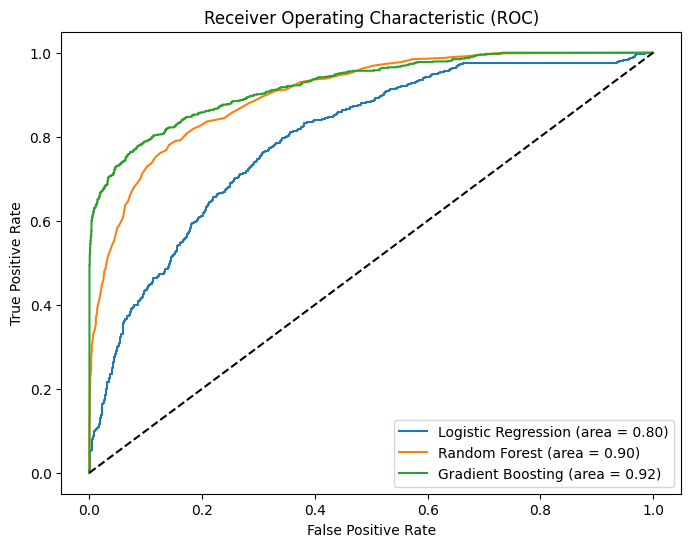

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assuming you have already split your data and trained your models

# Generate probability predictions
logistic_probs = logistic_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = random_forest_model.predict_proba(X_test)[:, 1]
gbm_probs = gbm_model.predict_proba(X_test)[:, 1]

# Calculate ROC Curve points and AUC for each model
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, logistic_probs)
roc_auc_logistic = auc(fpr_logistic, tpr_logistic)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_gbm, tpr_gbm, _ = roc_curve(y_test, gbm_probs)
roc_auc_gbm = auc(fpr_gbm, tpr_gbm)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_logistic, tpr_logistic, label='Logistic Regression (area = %0.2f)' % roc_auc_logistic)
plt.plot(fpr_rf, tpr_rf, label='Random Forest (area = %0.2f)' % roc_auc_rf)
plt.plot(fpr_gbm, tpr_gbm, label='Gradient Boosting (area = %0.2f)' % roc_auc_gbm)
plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


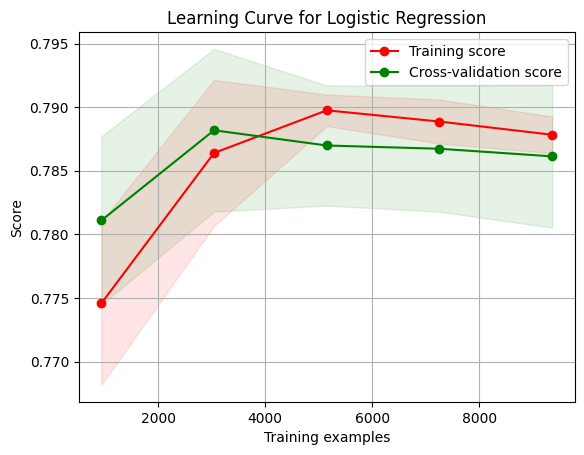

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# Example usage:
plot_learning_curve(logistic_model, "Learning Curve for Logistic Regression", X_train_scaled, y_train, cv=5)
plt.show()


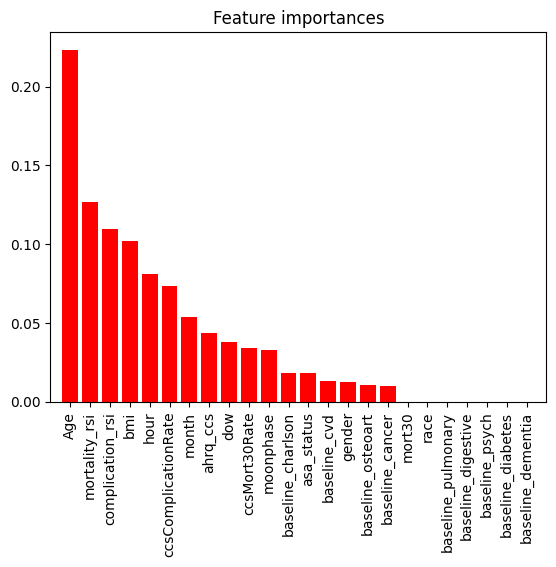

In [ ]:
# Feature Importance for Random Forest
importances = random_forest_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], color="r", align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Create a transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

# Fit and transform the data
X_processed = preprocessor.fit_transform(X)


## Conclusion

This notebook provided a structured analysis of surgical data, with insights into patient demographics and outcomes, followed by predictive modeling to estimate surgical complications. Further analysis can expand upon the models used or explore additional features from the dataset.
